#`Medical Expenses Using Linear Regression`

`Importing Dataset`

In [1]:
import requests

In [2]:
url = "https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv"

In [3]:
respose = requests.get(url)

In [4]:
# One time run only

with open('medical.csv' ,'wb') as file:
  file.write(respose.content)


In [5]:
import pandas as pd
import numpy as np

`Read Dataset`

In [6]:
medical_df =pd.read_csv('medical.csv')

In [7]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


`Analysis and visualization`

In [10]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
sns.set_style('darkgrid')


In [12]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


`AGE`

In [13]:
fig = px.histogram(medical_df , x = 'age' , marginal='box' , nbins=47 , title='Distribution of Age')
fig.update_layout(bargap=0.01)
fig.show()

`BMI`

In [14]:
fig = px.histogram(medical_df , x  = 'bmi' , marginal='box', color_discrete_sequence=['red']  , title='Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap = 0.1)
fig.show()

`CHARGES`

In [15]:
fig = px.histogram(medical_df , x = 'charges' , marginal='box' , color = 'smoker' , color_discrete_sequence=['green' , 'grey'] , title="Annual Medical Charges")
fig.update_layout(bargap = 0.1)
fig.show()

`Smoker`

In [16]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [17]:
px.histogram(medical_df , x = 'smoker' , color = 'sex' , title ='Smoker')

`Age and Charges`

In [18]:
fig = px.histogram(medical_df , x = 'sex' , y='charges' , color = 'smoker' , opacity=0.8 , hover_data =['sex'] , title= 'Age vs Charges')
# fig.update_traces(marker_size = 5)
fig.show()

`BMI and CHARGES`

In [19]:
fig = px.scatter(medical_df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

`Correlation`

In [20]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [21]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [22]:
smoker_values = {"no":0 ,
                 "Yes":1}

In [23]:
smoker_numric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numric)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



np.float64(nan)

In [24]:
medical_df.corr(numeric_only = True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


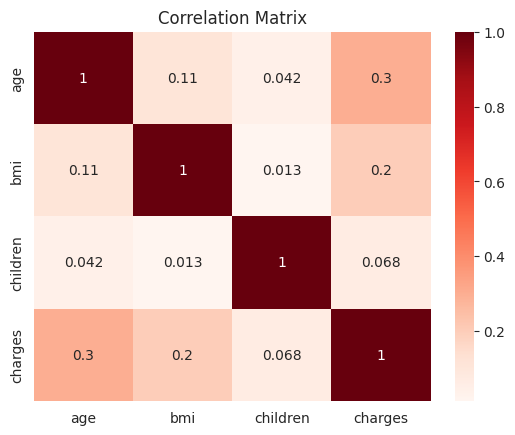

In [25]:
sns.heatmap(medical_df.corr(numeric_only=True) , cmap = 'Reds' , annot =True)
plt.title('Correlation Matrix');

#`Linear Regression using a Single Feature`

In [26]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

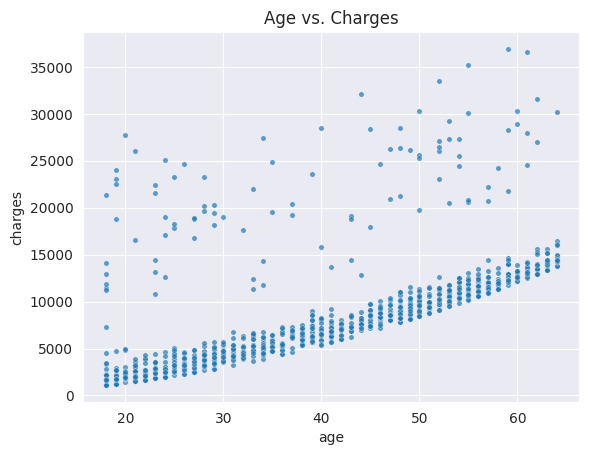

In [27]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age' , y='charges' , alpha=0.7 , s=15);

`Model`

Using formula;
charges = w * age + b;
To determine w and b for the line that best fits the data.

In [28]:
def estimate_charges(age,w,b):
  return w * age + b

Guessing the value for w and b.

In [29]:
w = 50
b = 100

In [30]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w , b)

Estimate charges using a line graph

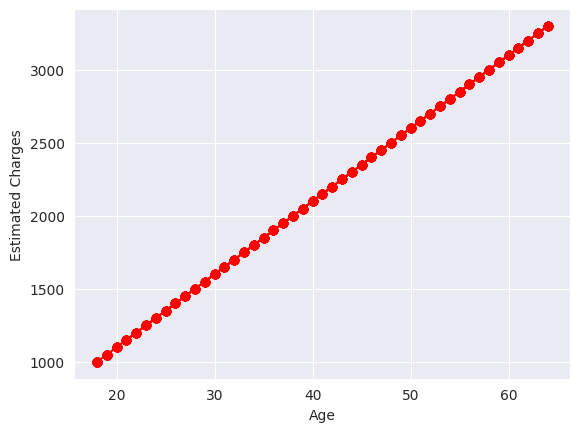

In [31]:
plt.plot(ages , estimated_charges , 'r-o');
plt.xlabel('Age');
plt.ylabel('Estimated Charges');

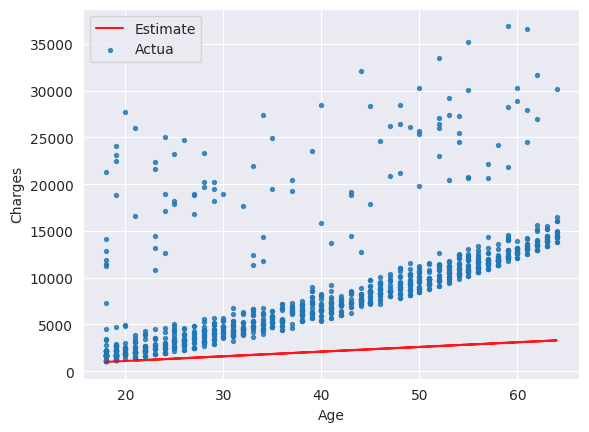

In [32]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges , 'r' , alpha = 0.9);
plt.scatter(ages , target, s=8 , alpha = 0.8);
plt.xlabel('Age');
plt.ylabel('Charges');
plt.legend(['Estimate' , 'Actua']);


In [33]:
def try_parameter(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges

  estimated_charges = estimate_charges(ages, w , b)
  plt.plot(ages, estimated_charges , 'r' , alpha=0.8);
  plt.scatter(ages, target, s=8 , alpha=0.8);
  plt.xlabel('Age');
  plt.ylabel('Charges')
  plt.legend(['Estimate' , 'Actual']);

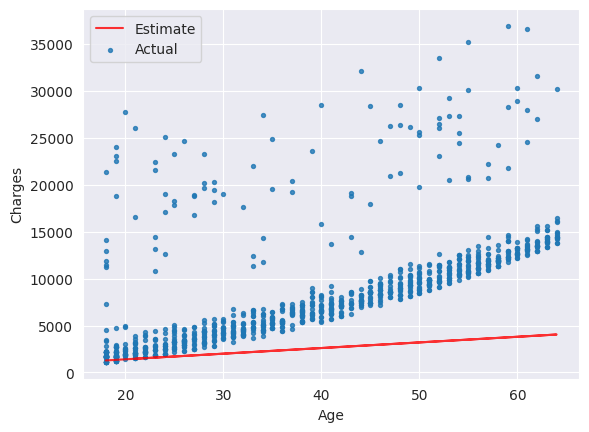

In [34]:
try_parameter(60,200)

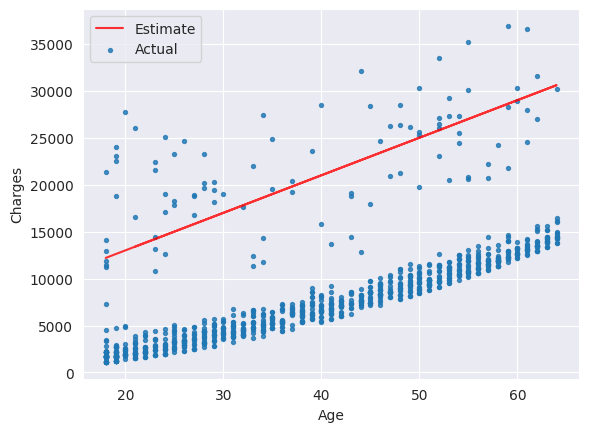

In [35]:
try_parameter(400 , 5000)

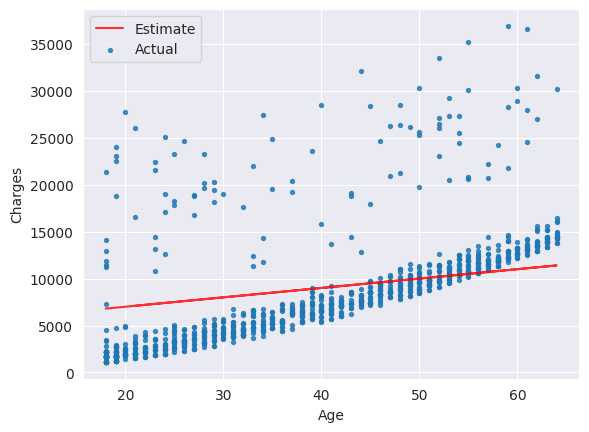

In [36]:
try_parameter(100 , 5000)

`Cost Function`

In [37]:
import numpy as np;


In [38]:
def rmse(targets , pedictions):
  return np.sqrt(np.mean(np.square(targets - predicted)))

In [39]:
w = 50
b = 100

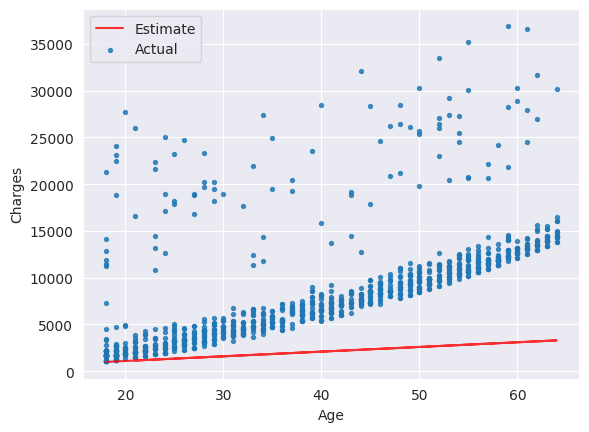

In [40]:
try_parameter(w , b);

In [41]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age , w , b)

In [42]:
rmse(targets , predicted)

np.float64(8461.949562575493)

In [43]:
def try_parameters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  predictions = estimate_charges(ages , w , b)

  plt.plot(ages , predictions , 'r' , alpha = 0.9);
  plt.scatter(ages, target , s= 8 , alpha = 0.8);
  plt.xlabel("Age");
  plt.ylabel("Charges")
  plt.legend(['Prediction' , 'Actual']);

  loss = rmse(target , predictions)
  print("RMSE Loss:" , loss)

RMSE Loss: 8461.949562575493


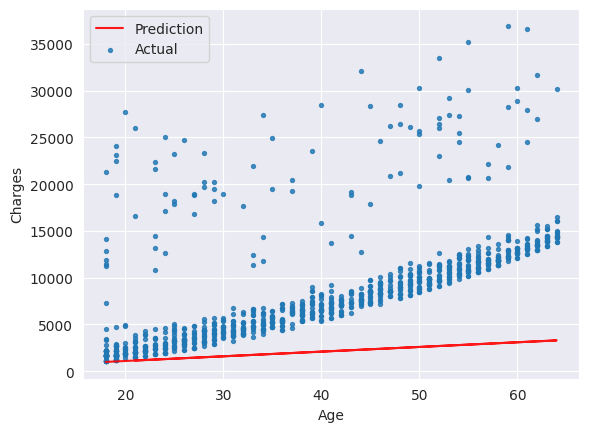

In [44]:
try_parameters(50,100)

`Liner Regression usign Scikit-learn`

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()

In [47]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [48]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print("Input.shape: " , inputs.shape)
print("Targets.shape: " , targets.shape)

Input.shape:  (1064, 1)
Targets.shape:  (1064,)


In [49]:
model.fit(inputs , targets)

LinearRegression()

In [50]:
model.predict(np.array([[23],[37],[61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [51]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [52]:
rmse(targets, predictions)

np.float64(8461.949562575493)

In [53]:
model.coef_

array([267.24891283])

In [54]:
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss: 8461.949562575493


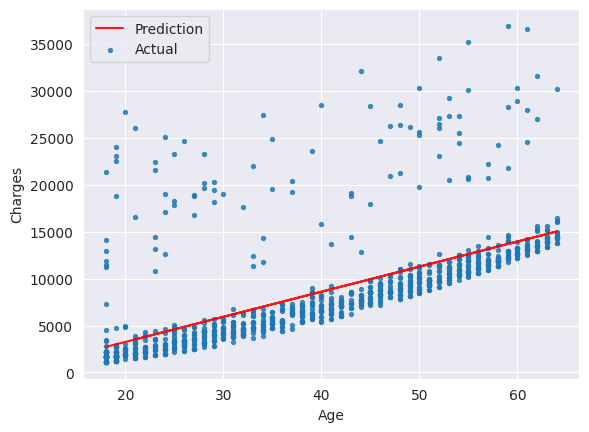

In [55]:
try_parameters(model.coef_ , model.intercept_)

Liner Regression Using Multiple Freatures

In [56]:
inputes, targets = non_smoker_df[['age' , 'bmi']] , non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets , predictions)
print("RMSE Loss:" , loss)

RMSE Loss: 8461.949562575493


In [57]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [58]:
fig = px.scatter(non_smoker_df , x='bmi' , y='charges' , title="BMI vs. Charges")
fig.update_traces(marker_size=5)
fig.show()

In [59]:
fig = px.scatter_3d(non_smoker_df , x='age' , y='bmi' , z = 'charges')
fig.update_traces( marker_size =2 , marker_opacity =0.7)
fig.show()

In [60]:
model.coef_, model.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [61]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [62]:
fig = px.scatter_3d(non_smoker_df , x='children' , y='bmi' , z='charges')
fig.update_traces(marker_size=2 , marker_opacity=0.7)
fig.show()

In [63]:
fig = px.strip(non_smoker_df , x='children' , y='bmi' , title = "Children Vs. Charges")
fig.update_traces(marker_size=2 , marker_opacity=0.7)
fig.show()

In [64]:
inputes , targets = non_smoker_df[['age' , 'bmi' , 'children']] , non_smoker_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss=rmse(targets , predictions)
print("RMSE: ", loss)

RMSE:  8461.949562575493


In [65]:
inputs, targets = medical_df[['age' , 'bmi' , 'children']] , medical_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets , predictions)
print("RMSE: " , loss)

RMSE:  8461.949562575493


Using Categorical Features for Machine Learning`

`Binary Categorices`

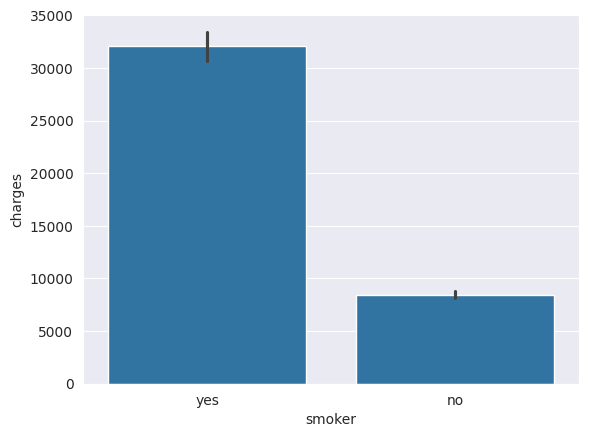

In [66]:
sns.barplot(data = medical_df , x = 'smoker' , y='charges');

In [69]:
smoker_codes = {'no':0,
                'yes':1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [70]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

In [71]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [72]:
inputes , targets = medical_df[['age' , 'bmi' , 'children' , 'smoker_code']] , medical_df['charges']
model = LinearRegression().fit(inputs , targets)
predictions = model.predict(inputs)
loss = rmse(targets , predictions)
print("Loss:" , loss)

Loss: 8461.949562575493


<Axes: xlabel='sex', ylabel='charges'>

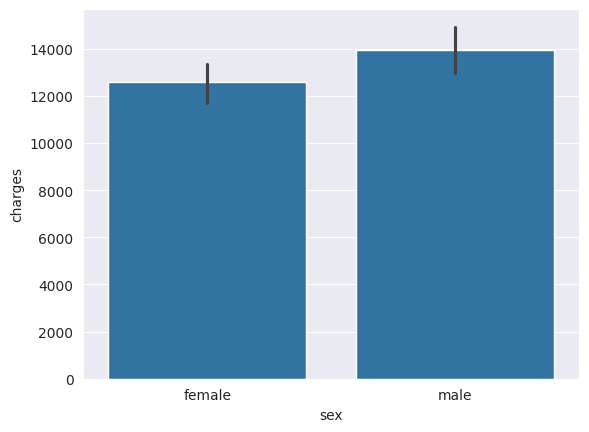

In [74]:
sns.barplot(data=medical_df , x='sex' , y='charges')

In [75]:
sex_codes = {'female':0 , 'male':1}
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [76]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [79]:
inputs = medical_df[['age' ,'bmi' , 'children','smoker_code' , 'sex_code']]
targets = medical_df['charges']
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets , predictions)
print('Loss:', loss)

Loss: 8461.949562575493


`One-hot Encoding`

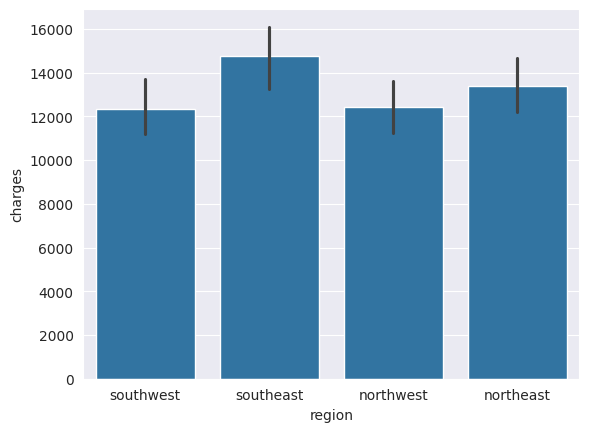

In [80]:
sns.barplot(data=medical_df , x='region' , y='charges');

In [82]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [85]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [90]:
medical_df[['northeast' , 'northwest','southeast' , 'southwest']] = one_hot

In [91]:
medical_df


,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,norhteast,northwest,southeast,southwest,northeast
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0,0.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0,1.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0,0.0


In [92]:
input_cols = ['age' , 'bmi' , 'children' , 'smoker_code' , 'sex_code' , 'northeast' , 'northwest' , 'southeast' , 'southwest']
inputs = medical_df[input_cols]
targets = medical_df['charges']

model = LinearRegression().fit(inputs , targets)
predictions = model.predict(inputs)
loss = rmse(targets , predictions)
print('Loss:' , loss)

Loss: 8461.949562575493


`Model Improvements`

Feature Scaling

In [93]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [94]:
model.intercept_

np.float64(-12525.547811195444)

In [95]:
weights_df = pd.DataFrame({
    'feature':np.append(input_cols, 1),
    'weight':np.append(model.coef_, model.intercept_)
})
weights_df

,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


In [97]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,norhteast,northwest,southeast,southwest,northeast
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0,0.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0,1.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0,0.0


In [99]:
from sklearn.preprocessing import StandardScaler

In [101]:
numeric_cols = ['age' , 'bmi' , 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [102]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [103]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [104]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [106]:
cat_cols = ['smoker_code' , 'sex_code' , 'northeast' , 'northwest' , 'southeast' , 'southwest']
categorical_data = medical_df[cat_cols].values

In [107]:

inputs = np.concatenate((scaled_inputs , categorical_data),axis = 1)
targets = medical_df.charges
model=LinearRegression().fit(inputs , targets)
predictions = model.predict(inputs)
loss = rmse(targets , predictions)
print('Loss:',loss)

Loss: 8461.949562575493


In [108]:
weights_df = pd.DataFrame({
    'feature':np.append(numeric_cols + cat_cols  ,1 ),
    'weight':np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending = False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


Creating a Test Set

In [110]:
from sklearn.model_selection import train_test_split


In [111]:
inputs_train , inputs_test , targets_train , targets_test = train_test_split(inputs ,targets , test_size = 0.1 )

In [112]:
model = LinearRegression().fit(inputs_train , targets_train)
predictions = model.predict(inputs_test)
loss = rmse(targets_test , predictions)
print('Test Loss:' , loss)

Test Loss: 7708.379881111512


In [113]:
predictions_train = model.predict(inputs_train)
loss = rmse(targets_train, predictions_train)
print('Training Loss:' , loss)

Training Loss: 8542.073528750863
